Expolartory data analysis

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [31]:
df=pd.read_csv('forestfire_dataset_cleaned.csv',sep=',')

In [32]:
df_copy=df.drop(['day','month','year'],axis=1)

In [33]:
##encoding of categories in classes

In [34]:
df.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='object')

In [ ]:
df_copy['Classes'] = df_copy['Classes'].astype(str)

In [ ]:
df_copy['Classes'] = df_copy['Classes'].str.strip()

In [37]:
df_copy['Classes']=np.where(df_copy['Classes'].str.contains('not fire'),0,1)

In [38]:
df_copy.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0,0


In [39]:
df_copy['Classes'].value_counts()

Classes
1    137
0    106
Name: count, dtype: int64

In [41]:
# This will show you exactly what the unique strings are
print(df_copy['Classes'].unique())

[0 1]


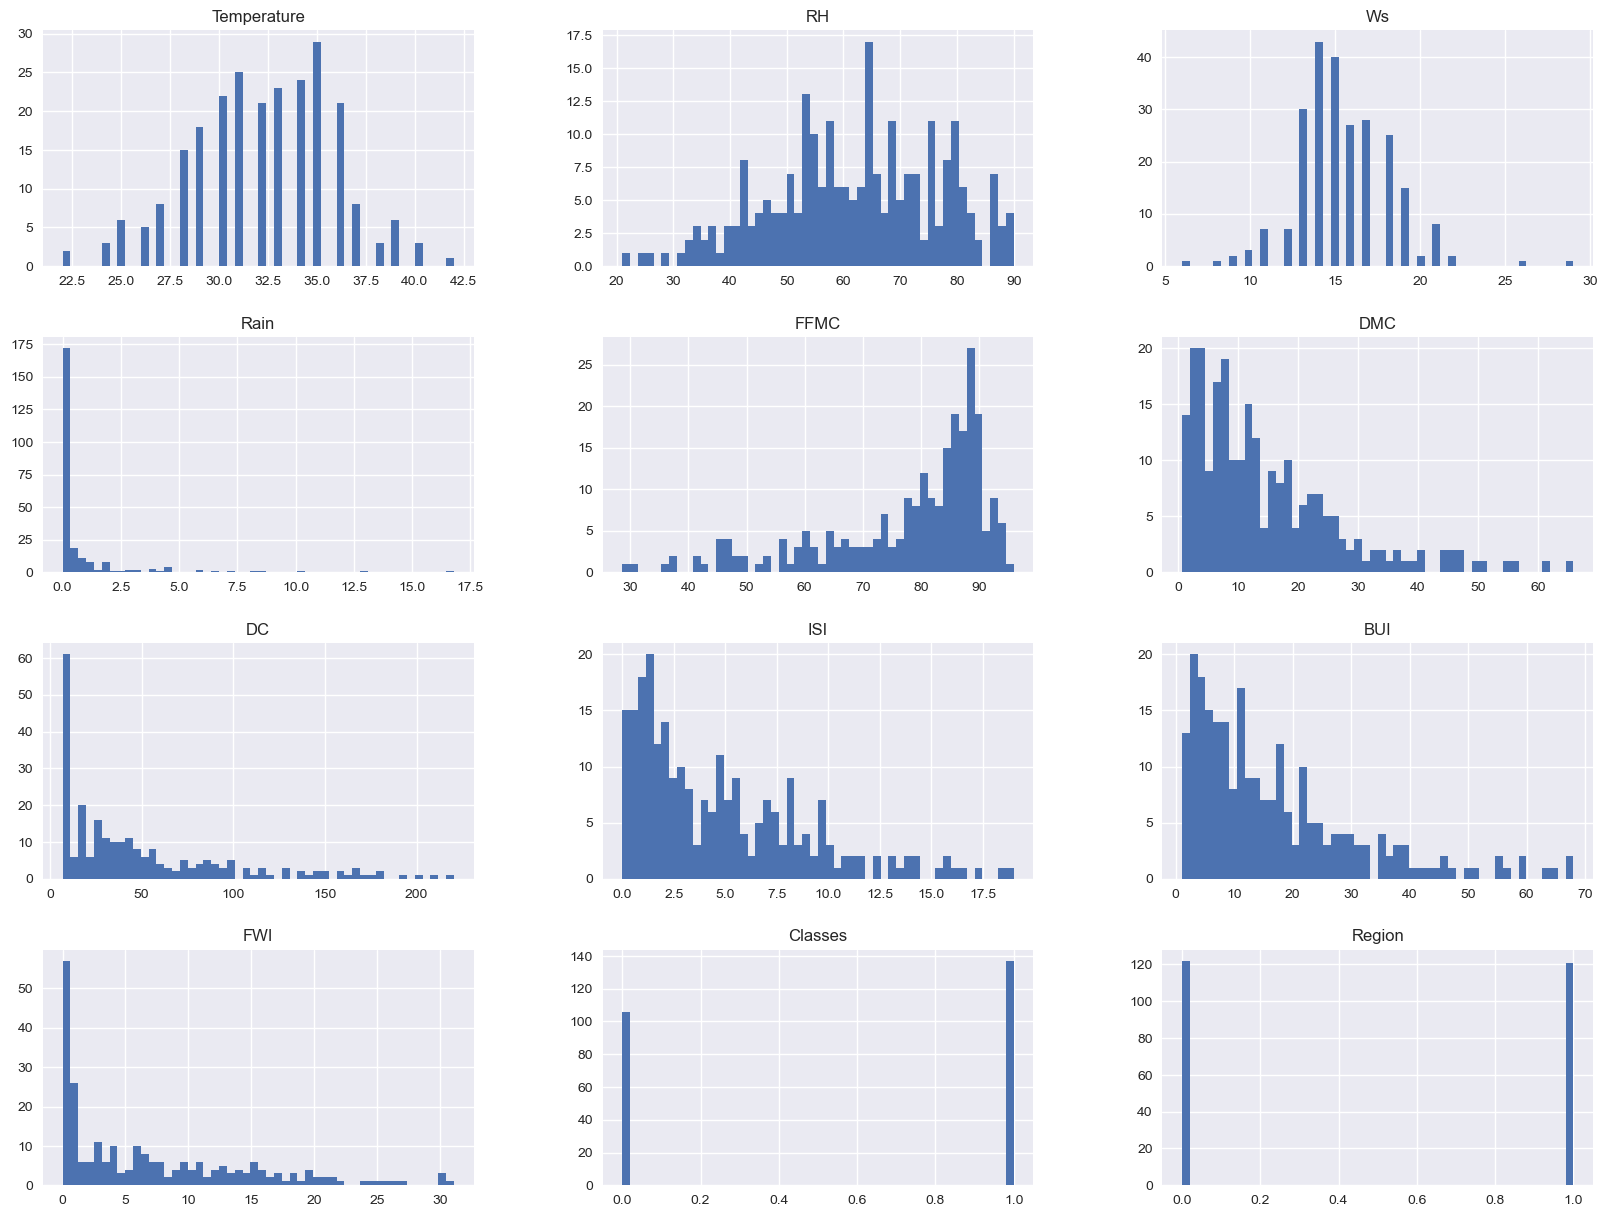

In [47]:
plt.style.use('seaborn-v0_8')
df_copy.hist(bins=50,figsize=(20,15))
plt.show()

In [48]:
## percentage of fire

In [51]:
percentage=df_copy['Classes'].value_counts(normalize=True)*100

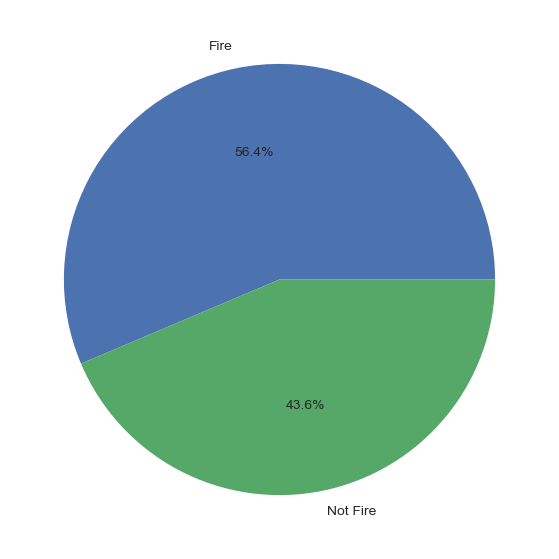

In [53]:
classeslabels=["Fire","Not Fire"]
plt.figure(figsize=(12,7))
plt.pie(percentage,labels=classeslabels,autopct='%1.1f%%')
plt.show()

Correlation

In [54]:
df_copy.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
Temperature,1.000000,-0.651400,-0.284510,-0.326492,0.676568,0.485687,0.376284,0.603871,0.459789,0.566670,0.516015,0.269555
RH,-0.651400,1.000000,0.244048,0.222356,-0.644873,-0.408519,-0.226941,-0.686667,-0.353841,-0.580957,-0.432161,-0.402682
Ws,-0.284510,0.244048,1.000000,0.171506,-0.166548,-0.000721,0.079135,0.008532,0.031438,0.032368,-0.069964,-0.181160
Rain,-0.326492,0.222356,0.171506,1.000000,-0.543906,-0.288773,-0.298023,-0.347484,-0.299852,-0.324422,-0.379097,-0.040013
FFMC,0.676568,-0.644873,-0.166548,-0.543906,1.000000,0.603608,0.507397,0.740007,0.592011,0.691132,0.769492,0.222241
DMC,0.485687,-0.408519,-0.000721,-0.288773,0.603608,1.000000,0.875925,0.680454,0.982248,0.875864,0.585658,0.192089
DC,0.376284,-0.226941,0.079135,-0.298023,0.507397,0.875925,1.000000,0.508643,0.941988,0.739521,0.511123,-0.078734
ISI,0.603871,-0.686667,0.008532,-0.347484,0.740007,0.680454,0.508643,1.000000,0.644093,0.922895,0.735197,0.263197
BUI,0.459789,-0.353841,0.031438,-0.299852,0.592011,0.982248,0.941988,0.644093,1.000000,0.857973,0.586639,0.089408
FWI,0.566670,-0.580957,0.032368,-0.324422,0.691132,0.875864,0.739521,0.922895,0.857973,1.000000,0.719216,0.197102


<Axes: >

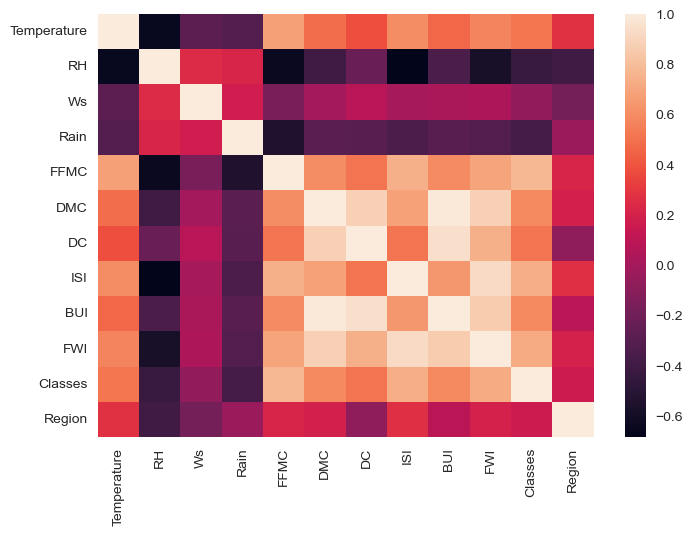

In [56]:
sns.heatmap(df_copy.corr())

<Axes: ylabel='FWI'>

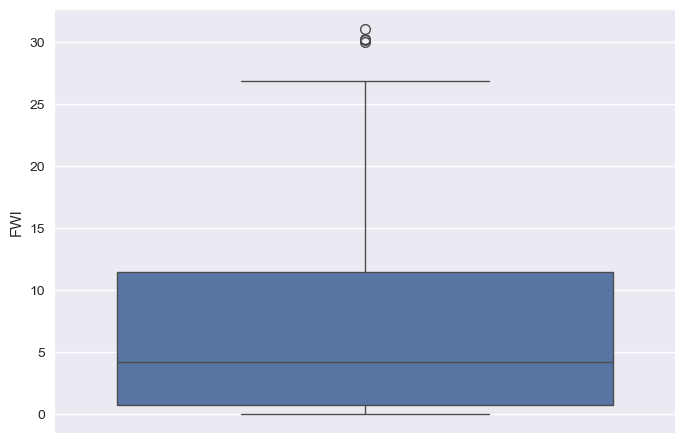

In [60]:
sns.boxplot(df_copy['FWI'])

In [61]:
###Monthly fire analyisis

In [62]:
df['Classes'] = df['Classes'].astype(str)

In [65]:
df['Classes']=np.where(df['Classes'].str.contains('not fire'),'not fire','fire')

In [66]:
df['Classes'].value_counts()

Classes
fire        137
not fire    106
Name: count, dtype: int64

<Axes: xlabel='month', ylabel='count'>

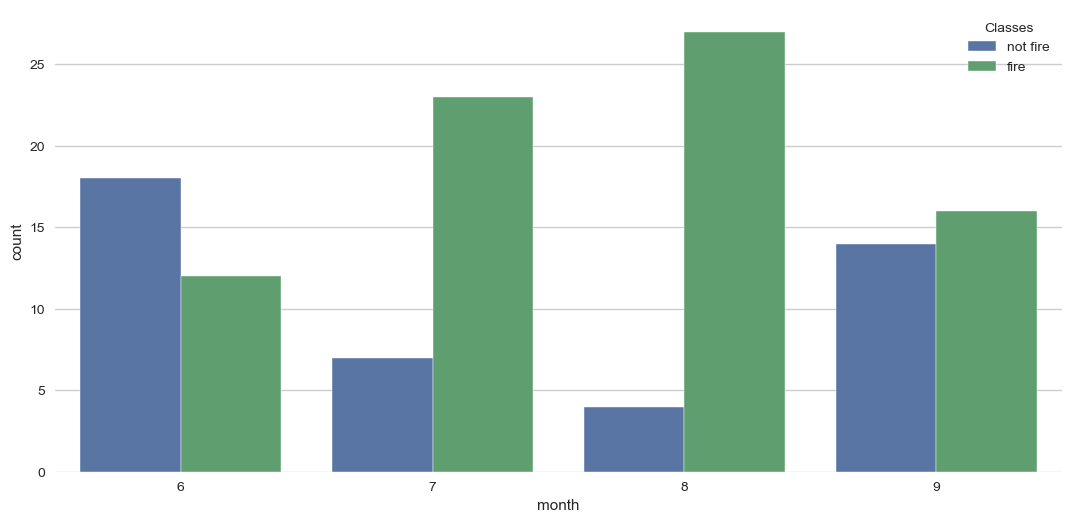

In [81]:
dftemp=df.loc[df['Region']==1] ##fire anaylis of seli-bell region
plt.subplots(figsize=(13,6))
sns.set_style('whitegrid')
sns.countplot(x='month',hue='Classes',data=dftemp)

<Axes: xlabel='month', ylabel='count'>

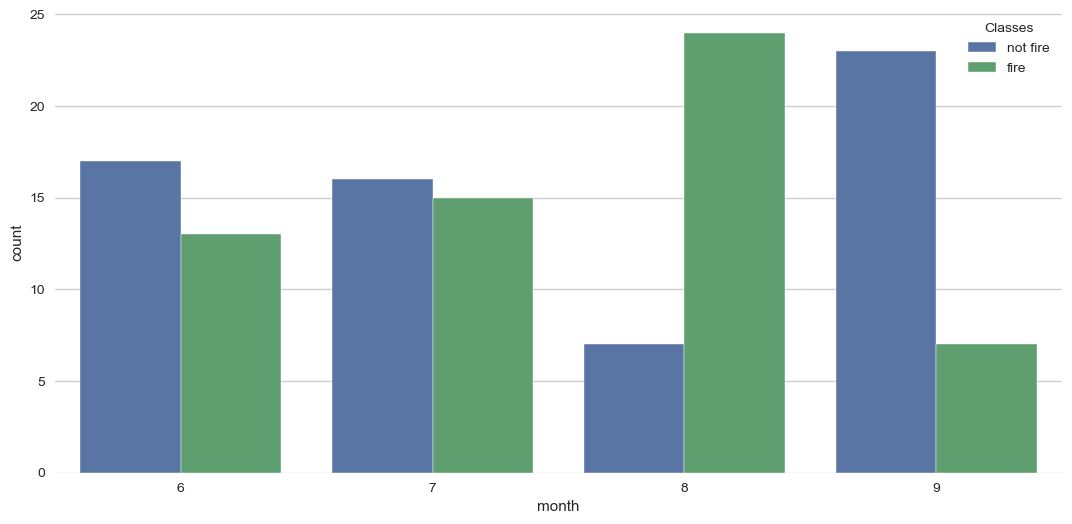

In [80]:
dftemp=df.loc[df['Region']==0]
plt.subplots(figsize=(13,6))
sns.set_style('whitegrid')
sns.countplot(x='month',hue='Classes',data=dftemp)

region 1 usally has a more balanced "fire vs not fire"count in june/sep.
aug and sep had most forest fired for both regions and most of the fires happened in aug and very high fires happened in only 3 months -june,july and aug